In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
 
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [2]:
np.random.seed(0)

In [3]:
X,y = make_blobs(n_samples = 5000, centers = [[4,4],[-2,1],[2,-3],[1,1]],cluster_std=0.9)

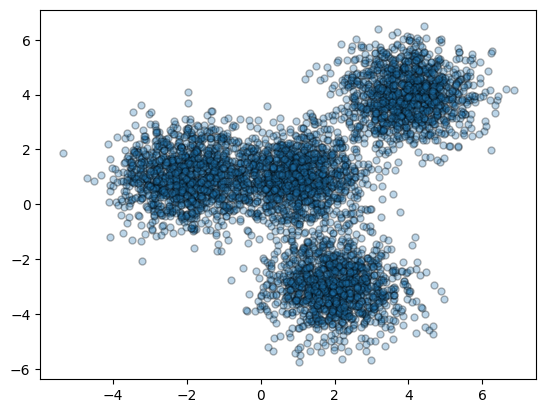

In [4]:
plt.scatter(X[:,0],X[:,1],marker=".",alpha=0.3,ec='k',s=100)

In [5]:
k_means = KMeans(init = "k-means++",n_clusters = 4,n_init = 12)

In [6]:
k_means.fit(X)

KMeans(n_clusters=4, n_init=12)

In [7]:
k_means_labels = k_means.labels_
k_means_labels

array([2, 1, 1, ..., 3, 2, 2], dtype=int32)

In [8]:
k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[ 0.99463358,  0.97011938],
       [ 1.9992416 , -3.02272243],
       [-2.04443402,  1.00712894],
       [ 3.97334234,  3.98758687]])

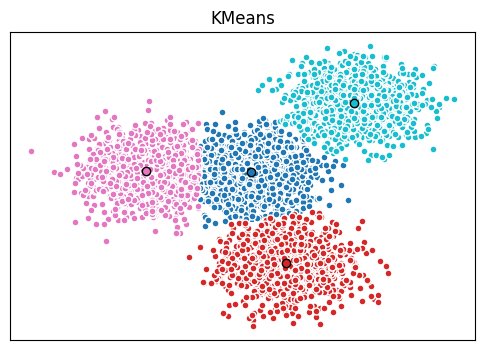

In [10]:
fig = plt.figure(figsize=(6,4))
colors = plt.cm.tab10(np.linspace(0,1,len(set(k_means_labels))))
ax=fig.add_subplot(1,1,1)

for k,co in zip(range(len([[4,4],[-2,-1],[2,-3],[1,1]])),colors):
    my_members = (k_means_labels ==k)
    cluster_center = k_means_cluster_centers[k]
    ax.plot(X[my_members,0],X[my_members,1],'w',markerfacecolor=co,marker='.',ms=10)
    ax.plot(cluster_center[0],cluster_center[1],'o',markerfacecolor=co,markeredgecolor='k',ms=6)
ax.set_title('KMeans')
ax.set_xticks(())
ax.set_yticks(())
plt.show()

In [ ]:
colors

array([[0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.83921569, 0.15294118, 0.15686275, 1.        ],
       [0.89019608, 0.46666667, 0.76078431, 1.        ],
       [0.09019608, 0.74509804, 0.81176471, 1.        ]])

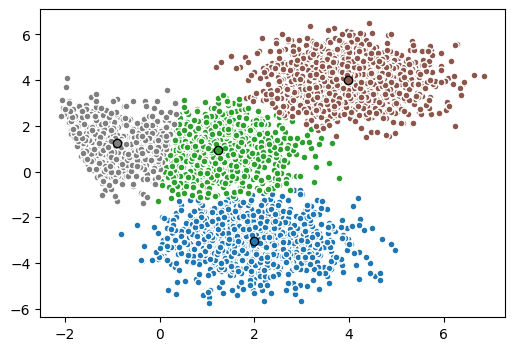

In [12]:
k_means3 = KMeans(init = "k-means++",n_clusters=5,n_init=12)
k_means3.fit(X)
fig = plt.figure(figsize=(6,4))
colors = plt.cm.tab10(np.linspace(0,1,len(set(k_means3.labels_))))
ax = fig.add_subplot(1,1,1)
for k,co in zip(range(len([[4,4],[-2,-1],[2,-3],[1,1]])),colors):
    my_members = (k_means3.labels_ == k)
    cluster_center = k_means3.cluster_centers_[k]
    ax.plot(X[my_members,0],X[my_members,1],'w',markerfacecolor=co,marker='.',ms=10)
    ax.plot(cluster_center[0],cluster_center[1],'o',markerfacecolor=co,markeredgecolor='k',ms=6)

### Cusstomer Segmentation with k-means

In [13]:
cust_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv")
cust_df

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2
...,...,...,...,...,...,...,...,...,...,...
845,846,27,1,5,26,0.548,1.220,NaN,NBA007,6.8
846,847,28,2,7,34,0.359,2.021,0.0,NBA002,7.0
847,848,25,4,0,18,2.802,3.210,1.0,NBA001,33.4
848,849,32,1,12,28,0.116,0.696,0.0,NBA012,2.9


In [14]:
cust_df = cust_df.drop('Address',axis = 1)

In [15]:
cust_df.dropna(inplace=True)
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 849
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      700 non-null    int64  
 1   Age              700 non-null    int64  
 2   Edu              700 non-null    int64  
 3   Years Employed   700 non-null    int64  
 4   Income           700 non-null    int64  
 5   Card Debt        700 non-null    float64
 6   Other Debt       700 non-null    float64
 7   Defaulted        700 non-null    float64
 8   DebtIncomeRatio  700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 54.7 KB


In [16]:
cust_df

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,5,47,1,31,253,9.308,8.908,0.0,7.2
...,...,...,...,...,...,...,...,...,...
844,845,41,1,7,43,0.694,1.198,0.0,4.4
846,847,28,2,7,34,0.359,2.021,0.0,7.0
847,848,25,4,0,18,2.802,3.210,1.0,33.4
848,849,32,1,12,28,0.116,0.696,0.0,2.9


In [17]:
X = cust_df.values[:,1:]
Clus_dataset = StandardScaler().fit_transform(X)

In [18]:
clusterNum = 3
k_means = KMeans(init = "k-means++",n_clusters=clusterNum,n_init=12)
k_means.fit(X)
labels = k_means.labels_

In [19]:
cust_df['Clus_km']=labels

In [20]:
labels

array([0, 2, 2, 0, 1, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 2,
       2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0,
       2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 1, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       2, 0, 2, 1, 0, 2, 0, 0, 0, 0, 1, 2, 0, 0, 2, 0, 0, 2, 2, 0, 2, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0,
       0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 2, 2,
       0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       2, 0, 0, 1, 0, 0, 0, 2, 0, 2, 2, 2, 0, 0, 0,

In [21]:
cust_df.groupby('Clus_km').mean()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Clus_km,,,,,,,,,
0,439.80226,32.775895,1.632768,6.169492,30.642185,1.003795,2.090910,0.284369,10.146893
1,374.00000,44.785714,3.000000,17.857143,219.714286,6.115429,11.546357,0.285714,8.064286
2,403.56129,41.103226,1.916129,15.135484,81.122581,3.024935,5.605258,0.180645,10.848387


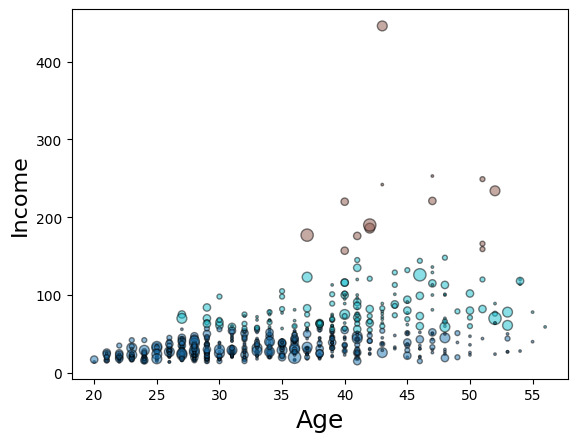

In [22]:
area = np.pi *(X[:,1])**2
plt.scatter(X[:,0],X[:,3],s=area,c=labels.astype(float), cmap='tab10', ec='k',alpha=0.5)
plt.xlabel('Age', fontsize=18)
plt.ylabel('Income', fontsize=16)
plt.show()

In [25]:
# Create interactive 3D scatter plot
fig = plt.figure(figsize=(5,15))
fig = px.scatter_3d(X, x=1, y=0, z=3, opacity=0.7, color=labels.astype(float))

fig.update_traces(marker=dict(size=5, line=dict(width=.25)), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800, scene=dict(
        xaxis=dict(title='Education'),
        yaxis=dict(title='Age'),
        zaxis=dict(title='Income')
    ))  # Remove color bar, resize plot

fig.show()


<Figure size 500x1500 with 0 Axes>

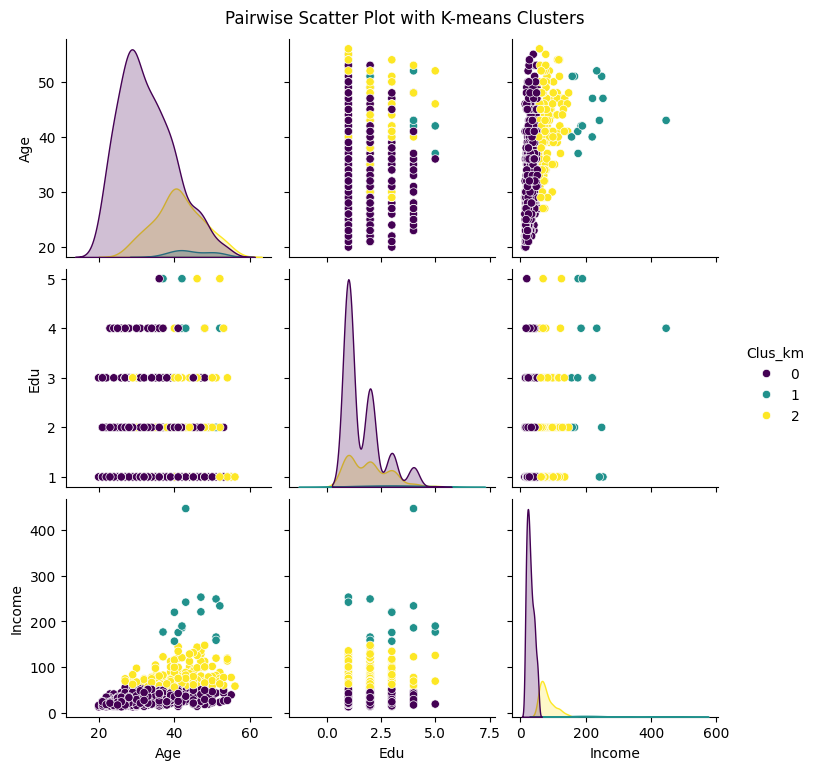

In [26]:
cust_df_sub = cust_df[['Age', 'Edu','Income','Clus_km']].copy() 
sns.pairplot(cust_df_sub, hue='Clus_km', palette='viridis', diag_kind='kde') 
plt.suptitle('Pairwise Scatter Plot with K-means Clusters', y=1.02)
plt.show()